# ResNet-18 Midjourney-Only Training Ablation

This notebook tests a narrower training setup for the Defactify binary classifier:

1. `train` keeps every `real` image but only samples AI images with `label_b = 5`
2. Each epoch uses one `real` image plus one Midjourney image per prompt group
3. `validation` and `test` stay flat manifest-driven datasets so we can compare against the broader multi-generator setup
4. An extra Midjourney-only evaluation loader is included to measure in-domain performance separately

The goal is to answer whether training on one AI generator instead of all five improves accuracy.


In [8]:
import csv
import os
import random
import time
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights

try:
    import matplotlib.pylab as plt
except Exception as exc:
    plt = None
    print(f"matplotlib is unavailable ({exc}). Plot cells will be skipped.")

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)


device: mps


In [9]:
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "requirements.txt").exists() and (PROJECT_ROOT.parent / "requirements.txt").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT_CANDIDATES = [
    PROJECT_ROOT / "output",
    PROJECT_ROOT.parent / "ensf617" / "output",
]

def choose_data_root(candidates):
    for candidate in candidates:
        if (
            (candidate / "metadata" / "train_manifest.csv").exists()
            and (candidate / "train").exists()
            and (candidate / "validation").exists()
            and (candidate / "test").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Could not find a usable Defactify output folder. "
        "Expected either PROJECT_ROOT/output or ../ensf617/output with manifests and image folders."
    )

DATA_ROOT = choose_data_root(DATA_ROOT_CANDIDATES)
TRAIN_MANIFEST = DATA_ROOT / "metadata" / "train_manifest.csv"
VAL_MANIFEST = DATA_ROOT / "metadata" / "validation_manifest.csv"
TEST_MANIFEST = DATA_ROOT / "metadata" / "test_manifest.csv"

TARGET_AI_LABEL_B = 5
TARGET_AI_NAME = "Midjourney"
INCLUDE_FULL_VAL_TEST = True
INCLUDE_TARGET_ONLY_VAL_TEST = True

image_size = 224
batch_size = 32
num_workers = 0
learning_rate = 1e-3
weight_decay = 1e-4
nepochs = 5
use_pretrained = True
freeze_backbone = True

checkpoint_dir = PROJECT_ROOT / "output" / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)
best_model_path = checkpoint_dir / "genai_resnet18_midjourney_only_best.pth"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_MANIFEST:", TRAIN_MANIFEST)


PROJECT_ROOT: /Users/williamwatson/meng_winter_courses/codex/ENSF617-Project
DATA_ROOT: /Users/williamwatson/meng_winter_courses/codex/ensf617/output
TRAIN_MANIFEST: /Users/williamwatson/meng_winter_courses/codex/ensf617/output/metadata/train_manifest.csv


In [10]:
def load_manifest_rows(manifest_path):
    with Path(manifest_path).open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))


def resolve_image_path(data_root, row):
    direct_path = Path(data_root) / row["image_path"]
    if direct_path.exists():
        return direct_path

    image_rel_path = Path(row["image_path"])
    split_name = image_rel_path.parts[0]
    flat_path = Path(data_root) / split_name / image_rel_path.name
    if flat_path.exists():
        return flat_path

    raise FileNotFoundError(f"Could not resolve image for row: {row}")


def load_prompt_groups(manifest_path, target_ai_label_b):
    rows = load_manifest_rows(manifest_path)
    rows.sort(key=lambda row: int(row["row_index"]))

    groups = []
    start = 0
    while start < len(rows):
        caption = rows[start]["caption"]
        end = start
        while end < len(rows) and rows[end]["caption"] == caption:
            end += 1

        group_rows = rows[start:end]
        groups.append(
            {
                "caption": caption,
                "rows": group_rows,
                "real_rows": [row for row in group_rows if row["label_a"] == "0"],
                "target_ai_rows": [
                    row
                    for row in group_rows
                    if row["label_a"] == "1" and int(row["label_b"]) == target_ai_label_b
                ],
            }
        )
        start = end

    return groups


class PromptBalancedMidjourneyTrainDataset(Dataset):
    def __init__(self, manifest_path, data_root, transform, target_ai_label_b, seed=42):
        self.data_root = Path(data_root)
        self.transform = transform
        self.target_ai_label_b = target_ai_label_b
        self.seed = seed
        self.classes = ["ai_generated", "real"]
        self.class_to_idx = {name: idx for idx, name in enumerate(self.classes)}

        self.all_rows = load_manifest_rows(manifest_path)
        self.prompt_groups = load_prompt_groups(manifest_path, target_ai_label_b)
        self.eligible_groups = [
            group for group in self.prompt_groups if group["real_rows"] and group["target_ai_rows"]
        ]
        self.skipped_groups = len(self.prompt_groups) - len(self.eligible_groups)
        self.records = []
        self.resample_epoch(0)

    def resample_epoch(self, epoch=0):
        rng = random.Random(self.seed + epoch)
        records = []
        for group in self.eligible_groups:
            records.extend(group["real_rows"])
            records.append(rng.choice(group["target_ai_rows"]))
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        row = self.records[index]
        image = Image.open(resolve_image_path(self.data_root, row)).convert("RGB")
        image = self.transform(image)
        label = self.class_to_idx[row["label_a_name"]]
        return image, label


class ManifestImageDataset(Dataset):
    def __init__(self, manifest_path, data_root, transform, ai_label_b_filter=None):
        self.data_root = Path(data_root)
        self.transform = transform
        self.classes = ["ai_generated", "real"]
        self.class_to_idx = {name: idx for idx, name in enumerate(self.classes)}

        rows = load_manifest_rows(manifest_path)
        if ai_label_b_filter is None:
            self.records = rows
        else:
            allowed = set(ai_label_b_filter)
            self.records = [
                row
                for row in rows
                if row["label_a"] == "0" or int(row["label_b"]) in allowed
            ]

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        row = self.records[index]
        image = Image.open(resolve_image_path(self.data_root, row)).convert("RGB")
        image = self.transform(image)
        label = self.class_to_idx[row["label_a_name"]]
        return image, label


In [11]:
train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = PromptBalancedMidjourneyTrainDataset(
    manifest_path=TRAIN_MANIFEST,
    data_root=DATA_ROOT,
    transform=train_transform,
    target_ai_label_b=TARGET_AI_LABEL_B,
    seed=SEED,
)

val_dataset = ManifestImageDataset(
    manifest_path=VAL_MANIFEST,
    data_root=DATA_ROOT,
    transform=eval_transform,
)
test_dataset = ManifestImageDataset(
    manifest_path=TEST_MANIFEST,
    data_root=DATA_ROOT,
    transform=eval_transform,
)

target_val_dataset = ManifestImageDataset(
    manifest_path=VAL_MANIFEST,
    data_root=DATA_ROOT,
    transform=eval_transform,
    ai_label_b_filter={TARGET_AI_LABEL_B},
)
target_test_dataset = ManifestImageDataset(
    manifest_path=TEST_MANIFEST,
    data_root=DATA_ROOT,
    transform=eval_transform,
    ai_label_b_filter={TARGET_AI_LABEL_B},
)

trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
valloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
testloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
target_valloader = DataLoader(target_val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
target_testloader = DataLoader(target_test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

class_names = train_dataset.classes


In [12]:
print(class_names)
print("Train manifest rows:", len(train_dataset.all_rows))
print("Train eligible prompt groups:", len(train_dataset.eligible_groups), "| skipped:", train_dataset.skipped_groups)
print("Train effective epoch size:", len(train_dataset))
print("Train real images kept each epoch:", sum(len(group["real_rows"]) for group in train_dataset.eligible_groups))
print(f"Train {TARGET_AI_NAME} images sampled each epoch:", len(train_dataset.eligible_groups))
print("Validation rows (full):", len(val_dataset))
print("Validation rows (real + target):", len(target_val_dataset))
print("Test rows (full):", len(test_dataset))
print("Test rows (real + target):", len(target_test_dataset))


['ai_generated', 'real']
Train manifest rows: 14700
Train eligible prompt groups: 2449 | skipped: 2
Train effective epoch size: 4898
Train real images kept each epoch: 2449
Train Midjourney images sampled each epoch: 2449
Validation rows (full): 3100
Validation rows (real + target): 1049
Test rows (full): 3500
Test rows (real + target): 1179


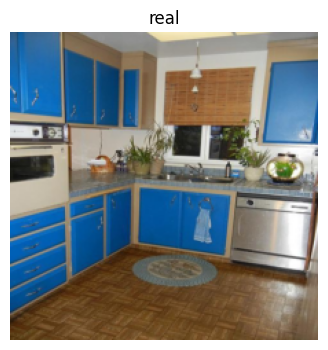

In [13]:
train_iterator = iter(trainloader)
sample_images, sample_labels = next(train_iterator)

if plt is None:
    print("Skipping sample visualization because matplotlib is unavailable.")
else:
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    sample_image = sample_images[0].cpu() * std + mean
    sample_image = sample_image.clamp(0, 1)

    plt.figure(figsize=(4, 4))
    plt.imshow(sample_image.permute(1, 2, 0).numpy())
    plt.title(class_names[sample_labels[0].item()])
    plt.axis("off")
    plt.show()


In [14]:
class AiGenModel(nn.Module):
    def __init__(self, num_classes=2, use_pretrained=True, freeze_backbone=True):
        super().__init__()

        self.use_pretrained = use_pretrained
        self.freeze_backbone = freeze_backbone

        weights = ResNet18_Weights.DEFAULT if use_pretrained else None
        self.feature_extractor = models.resnet18(weights=weights)

        if self.use_pretrained and self.freeze_backbone:
            for name, param in self.feature_extractor.named_parameters():
                if not name.startswith("fc."):
                    param.requires_grad = False

        in_features = self.feature_extractor.fc.in_features
        self.feature_extractor.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.feature_extractor(x)


class_names = globals().get("class_names", train_dataset.classes)
num_classes = len(class_names)
net = AiGenModel(
    num_classes=num_classes,
    use_pretrained=use_pretrained,
    freeze_backbone=freeze_backbone,
).to(device)
print(net)


AiGenModel(
  (feature_extractor): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tr

In [15]:
criterion = nn.CrossEntropyLoss()
trainable_params = [param for param in net.parameters() if param.requires_grad]
optimizer = optim.AdamW(trainable_params, lr=learning_rate, weight_decay=weight_decay)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)


In [16]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")

for epoch in range(nepochs):
    train_dataset.resample_epoch(epoch)

    epoch_start_time = time.perf_counter()
    net.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in trainloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_train_loss / len(train_dataset)
    train_acc = train_correct / max(train_total, 1)

    net.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in valloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = net(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_dataset)
    val_acc = val_correct / max(val_total, 1)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1}/{nepochs} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(net.state_dict(), best_model_path)
        print("Saved new best model to", best_model_path)

print("Finished training")


Epoch 1/5 | train_loss=0.4812 train_acc=0.7740 | val_loss=0.7859 val_acc=0.5755
Saved new best model to /Users/williamwatson/meng_winter_courses/codex/ENSF617-Project/output/checkpoints/genai_resnet18_midjourney_only_best.pth
Epoch 2/5 | train_loss=0.3167 train_acc=0.8779 | val_loss=0.8475 val_acc=0.5906
Epoch 3/5 | train_loss=0.2765 train_acc=0.8930 | val_loss=0.6770 val_acc=0.6774
Saved new best model to /Users/williamwatson/meng_winter_courses/codex/ENSF617-Project/output/checkpoints/genai_resnet18_midjourney_only_best.pth
Epoch 4/5 | train_loss=0.2660 train_acc=0.8957 | val_loss=0.7309 val_acc=0.6713
Epoch 5/5 | train_loss=0.2314 train_acc=0.9143 | val_loss=0.8874 val_acc=0.6194
Finished training


In [17]:
net = AiGenModel(
    num_classes=len(globals().get("class_names", train_dataset.classes)),
    use_pretrained=use_pretrained,
    freeze_backbone=freeze_backbone,
).to(device)
net.load_state_dict(torch.load(best_model_path, map_location=device))
net.eval()


AiGenModel(
  (feature_extractor): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tr

In [18]:
def evaluate_model(model, loader, dataset_name):
    class_names = globals().get("class_names", train_dataset.classes)
    total = 0
    correct = 0
    total_loss = 0.0
    class_correct = {name: 0 for name in class_names}
    class_total = {name: 0 for name in class_names}

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            for label, pred in zip(labels, predicted):
                class_name = class_names[label.item()]
                class_total[class_name] += 1
                if label.item() == pred.item():
                    class_correct[class_name] += 1

    metrics = {
        "dataset": dataset_name,
        "loss": total_loss / max(total, 1),
        "accuracy": correct / max(total, 1),
        "accuracy_percent": 100 * correct / max(total, 1),
    }

    per_class_accuracy = {}
    for class_name in class_names:
        per_class_accuracy[class_name] = class_correct[class_name] / max(class_total[class_name], 1)

    metrics["per_class_accuracy"] = per_class_accuracy
    metrics["balanced_accuracy"] = sum(per_class_accuracy.values()) / len(per_class_accuracy)
    return metrics


full_val_metrics = evaluate_model(net, valloader, "validation_full")
full_test_metrics = evaluate_model(net, testloader, "test_full")
target_val_metrics = evaluate_model(net, target_valloader, "validation_real_plus_midjourney")
target_test_metrics = evaluate_model(net, target_testloader, "test_real_plus_midjourney")

for metrics in [full_val_metrics, full_test_metrics, target_val_metrics, target_test_metrics]:
    print(metrics["dataset"])
    print("  loss:", f"{metrics['loss']:.4f}")
    print("  accuracy:", f"{metrics['accuracy_percent']:.2f}%")
    print("  balanced_accuracy:", f"{100 * metrics['balanced_accuracy']:.2f}%")
    for class_name, class_acc in metrics["per_class_accuracy"].items():
        print(f"  {class_name}: {100 * class_acc:.2f}%")
    print()


validation_full
  loss: 0.6770
  accuracy: 67.74%
  balanced_accuracy: 74.56%
  ai_generated: 64.39%
  real: 84.74%

test_full
  loss: 1.0080
  accuracy: 54.40%
  balanced_accuracy: 58.23%
  ai_generated: 52.35%
  real: 64.10%

validation_real_plus_midjourney
  loss: 0.2511
  accuracy: 89.99%
  balanced_accuracy: 89.86%
  ai_generated: 94.98%
  real: 84.74%

test_real_plus_midjourney
  loss: 0.8940
  accuracy: 62.34%
  balanced_accuracy: 62.28%
  ai_generated: 60.46%
  real: 64.10%



In [19]:
BASELINE_FIVE_GENERATOR_TEST_ACCURACY = None

if BASELINE_FIVE_GENERATOR_TEST_ACCURACY is None:
    print(
        "Set BASELINE_FIVE_GENERATOR_TEST_ACCURACY to the reference full-generator run "
        "if you want an automatic delta here."
    )
else:
    delta = full_test_metrics["accuracy"] - BASELINE_FIVE_GENERATOR_TEST_ACCURACY
    print("Full-test accuracy delta vs 5-generator baseline:", f"{100 * delta:+.2f}%")


Set BASELINE_FIVE_GENERATOR_TEST_ACCURACY to the reference full-generator run if you want an automatic delta here.


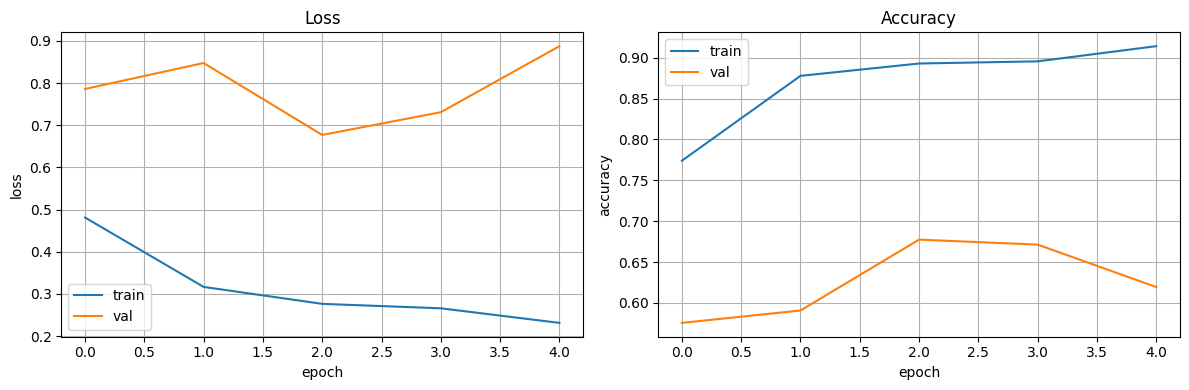

In [20]:
if plt is None:
    print("Skipping training curves because matplotlib is unavailable.")
else:
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="val")
    plt.title("Loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="train")
    plt.plot(history["val_acc"], label="val")
    plt.title("Accuracy")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
